#### Library

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
# import warnings
# warnings.filterwarnings('ignore')

#### EDA

In [21]:
# 데이터 로드 및 전처리
df = pd.read_csv('data2.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# 결측값 처리 (선형 보간)
df_filled = df.interpolate(method='linear')

print("=== 데이터 기본 정보 ===")
print(f"데이터 기간: {df.index.min()} ~ {df.index.max()}")
print(f"총 관측치 수: {len(df)}")
print(f"변수 개수: {df.shape[1]}")
print("\n결측값 정보:")
print(df.isnull().sum())

=== 데이터 기본 정보 ===
데이터 기간: 2015-08-31 00:00:00 ~ 2025-07-31 00:00:00
총 관측치 수: 120
변수 개수: 6

결측값 정보:
price                0
production           5
nev-sales            1
wind-energy-index    0
magnet-exports       1
event-score          0
dtype: int64


In [22]:
pre_covid = df_filled['2015-08-31':'2020-09-30']
covid_impact = df_filled['2020-10-31':'2023-04-30'] 
recovery = df_filled['2023-05-01':]
total = df_filled

# 기술통계 분석 (왜도, 첨도 포함)
def describe_with_skew_kurt(data, period_name):
    print(f"\n=== {period_name} 기술통계량 ===")
    print(data.describe())
    
    print(f"왜도(Skewness) & 첨도(Kurtosis)")
    for col in data.columns:
        series_data = data[col].dropna()
        if len(series_data) > 3:  # 최소 데이터 확인
            skewness = stats.skew(series_data)
            kurtosis = stats.kurtosis(series_data)
            print(f"  {col}: Skewness={skewness:>8.3f}, Kurtosis={kurtosis:>8.3f}")

# 기술통계 분석
describe_with_skew_kurt(pre_covid, "코로나 이전")

describe_with_skew_kurt(covid_impact, "코로나 영향")

describe_with_skew_kurt(recovery, "회복기")

describe_with_skew_kurt(total, "전체 데이터")


=== 코로나 이전 기술통계량 ===
               price     production      nev-sales  wind-energy-index  \
count      62.000000      62.000000      62.000000          62.000000   
mean   382959.677419   51569.959677  123788.322581          12.888065   
std     60460.480141   28818.402144   63444.832916           1.342176   
min    307500.000000     238.000000   26292.000000          10.470000   
25%    334500.000000   29749.000000   75571.500000          12.117500   
50%    373750.000000   47548.000000  119095.000000          12.935000   
75%    409375.000000   77397.250000  156252.500000          13.287500   
max    590000.000000  103823.000000  316111.000000          17.380000   

       magnet-exports  event-score  
count    6.200000e+01    62.000000  
mean     3.775495e+08    -0.307283  
std      6.422464e+07     0.564612  
min      1.771222e+08    -0.778978  
25%      3.567380e+08    -0.724713  
50%      3.959333e+08    -0.586742  
75%      4.207511e+08     0.008672  
max      4.704484e+08   

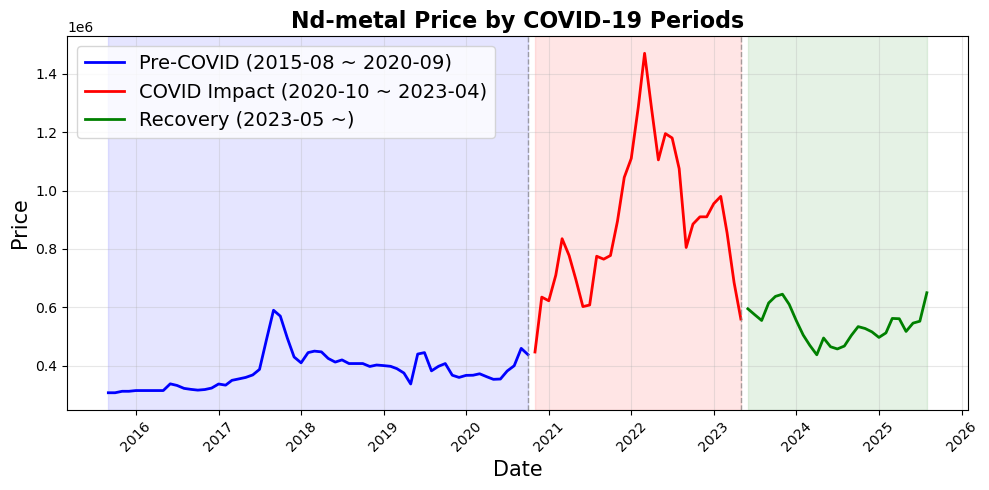

In [23]:
# Price 시계열 구간별 색깔 표시
plt.figure(figsize=(10, 5))

# 각 구간별로 다른 색깔로 플롯
plt.plot(pre_covid.index, pre_covid['price'], 
         color='blue', linewidth=2, label='Pre-COVID (2015-08 ~ 2020-09)', alpha=1.0)

plt.plot(covid_impact.index, covid_impact['price'], 
         color='red', linewidth=2, label='COVID Impact (2020-10 ~ 2023-04)', alpha=1.0)

plt.plot(recovery.index, recovery['price'], 
         color='green', linewidth=2, label='Recovery (2023-05 ~)', alpha=1.0)

# 구간 경계선 표시
plt.axvline(x=pd.Timestamp('2020-09-30'), color='gray', linestyle='--', alpha=0.7, linewidth=1)
plt.axvline(x=pd.Timestamp('2023-04-30'), color='gray', linestyle='--', alpha=0.7, linewidth=1)

# 구간 배경 음영 처리 (선택사항)
plt.axvspan(pre_covid.index.min(), pre_covid.index.max(), 
           alpha=0.1, color='blue', label='_nolegend_')
plt.axvspan(covid_impact.index.min(), covid_impact.index.max(), 
           alpha=0.1, color='red', label='_nolegend_')
plt.axvspan(recovery.index.min(), recovery.index.max(), 
           alpha=0.1, color='green', label='_nolegend_')

plt.title('Nd-metal Price by COVID-19 Periods',fontweight='bold', fontsize=16)
plt.xlabel('Date', fontsize=15)
plt.ylabel('Price', fontsize=15)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

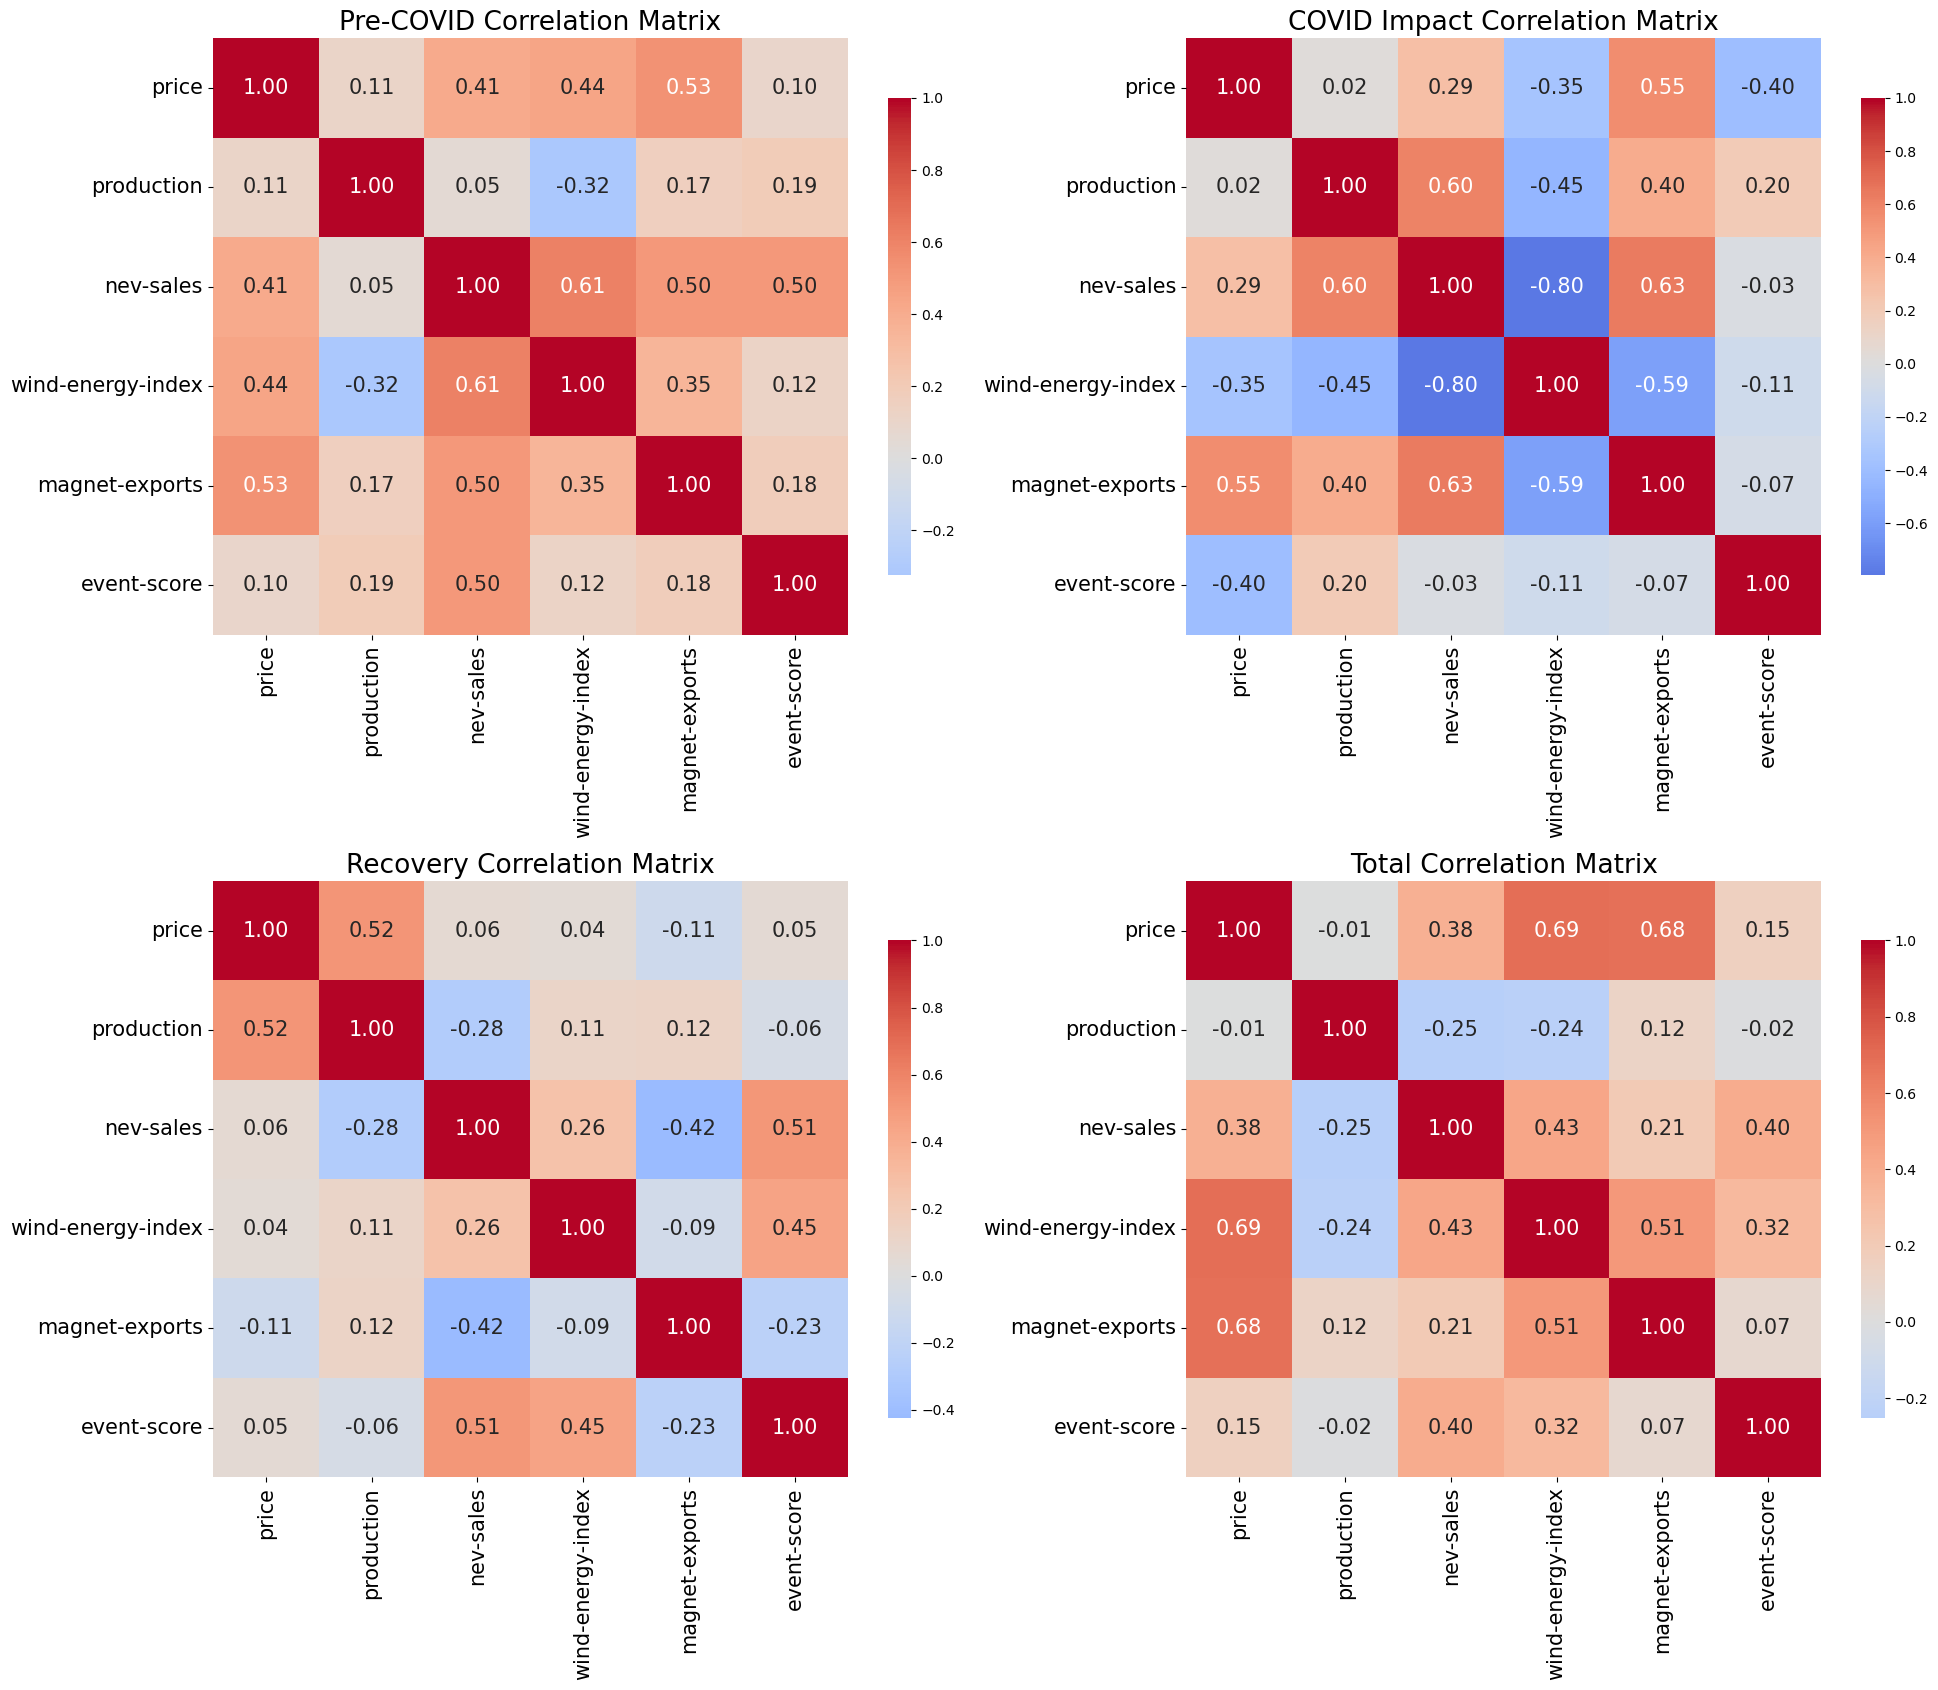

In [27]:
# 구간별 상관관계 분석
periods = {
    'Pre-COVID': pre_covid,
    'COVID Impact': covid_impact, 
    'Recovery': recovery,
    'Total': total
}

# 각 구간별 상관관계 히트맵
fig, axes = plt.subplots(2, 2, figsize=(20, 17))
axes = axes.flatten()

for idx, (period_name, data) in enumerate(periods.items()):
    if len(data) > 0:
        correlation_matrix = data.corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                   fmt='.2f', ax=axes[idx], cbar_kws={'shrink': 0.8},
                   annot_kws={'size': 15})  # 내부 숫자 크기
        axes[idx].set_title(f'{period_name} Correlation Matrix', fontsize=19)
        
        # x축, y축 레이블 크기 조정
        axes[idx].tick_params(axis='x', labelsize=15)
        axes[idx].tick_params(axis='y', labelsize=15)
        
    else:
        axes[idx].text(0.5, 0.5, 'No Data', ha='center', va='center', 
                      transform=axes[idx].transAxes, fontsize=16)
        axes[idx].set_title(f'{period_name} Correlation Matrix', fontsize=16)

plt.tight_layout()
plt.show()

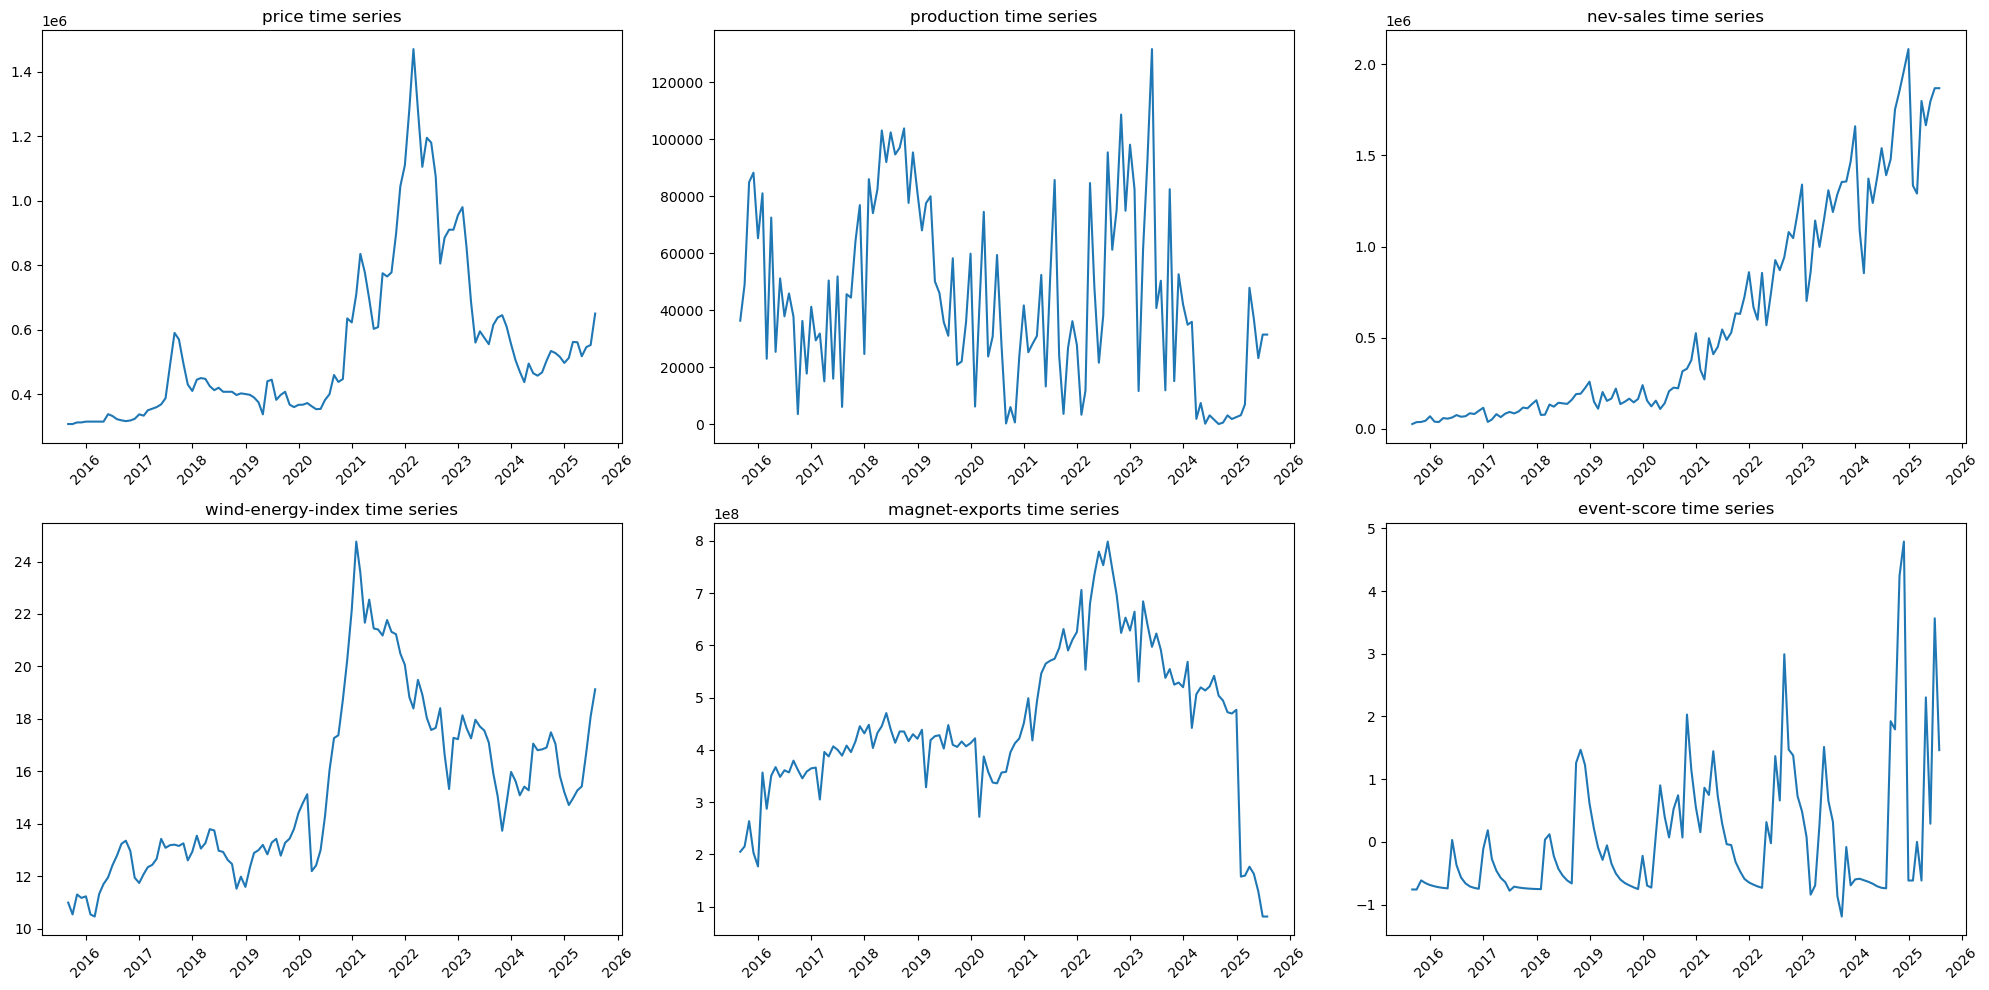

In [8]:
# 시계열 플롯
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
variables = ['price', 'production', 'nev-sales', 
            'wind-energy-index', 'magnet-exports', 'event-score']

for i, var in enumerate(variables):
    row, col = i // 3, i % 3
    if var in df_filled.columns:
        axes[row, col].plot(df_filled.index, df_filled[var])
        axes[row, col].set_title(f'{var} time series')
        axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [9]:
# 정상성 검정 (Augmented Dickey-Fuller Test)
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'\n{name} ADF 검정 결과:')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print("결과: 정상시계열 (p < 0.05)")
    else:
        print("결과: 비정상시계열 (p >= 0.05)")
    return result[1] <= 0.05

print("=== 정상성 검정 ===")
stationarity_results = {}
for var in df_filled.columns:
    stationarity_results[var] = check_stationarity(df_filled[var], var)

=== 정상성 검정 ===

price ADF 검정 결과:
ADF Statistic: -2.092309
p-value: 0.247618
Critical Values:
	1%: -3.494
	5%: -2.889
	10%: -2.582
결과: 비정상시계열 (p >= 0.05)

production ADF 검정 결과:
ADF Statistic: -2.280967
p-value: 0.178180
Critical Values:
	1%: -3.488
	5%: -2.887
	10%: -2.580
결과: 비정상시계열 (p >= 0.05)

nev-sales ADF 검정 결과:
ADF Statistic: 1.630818
p-value: 0.997947
Critical Values:
	1%: -3.494
	5%: -2.889
	10%: -2.582
결과: 비정상시계열 (p >= 0.05)

wind-energy-index ADF 검정 결과:
ADF Statistic: -1.844162
p-value: 0.358767
Critical Values:
	1%: -3.487
	5%: -2.886
	10%: -2.580
결과: 비정상시계열 (p >= 0.05)

magnet-exports ADF 검정 결과:
ADF Statistic: -1.267370
p-value: 0.643965
Critical Values:
	1%: -3.493
	5%: -2.889
	10%: -2.581
결과: 비정상시계열 (p >= 0.05)

event-score ADF 검정 결과:
ADF Statistic: -3.309004
p-value: 0.014481
Critical Values:
	1%: -3.489
	5%: -2.887
	10%: -2.580
결과: 정상시계열 (p < 0.05)


#### Linear Regression

In [115]:
# 코로나 이전 데이터 회귀분석
# 독립변수와 종속변수 분리
X_vars = ['production', 'nev-sales', 
          'wind-energy-index', 'magnet-exports', 'event-score']
X = pre_covid[X_vars].dropna()
y = pre_covid.loc[X.index, 'price']
y = np.log(y).diff() # y를 로그 수익률로 변경

# 첫 행에 NaN이 생기므로 X와 y에서 모두 제거
y = y.dropna()
X = X.loc[y.index]

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 다중회귀분석 (OLS)
print("\n=== 코로나 이전 다중회귀분석 (OLS) 결과 ===")
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

# 모델 진단
print("\n=== 모델 진단 ===")

# 1) 잔차의 정규성 검정
from scipy import stats
residuals = ols_model.resid
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk 정규성 검정: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# 2) 이분산성 검정 (Breusch-Pagan Test)
bp_test = het_breuschpagan(residuals, X_train_const)
print(f"Breusch-Pagan 이분산성 검정: LM statistic={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")

# 3) 자기상관 검정 (Durbin-Watson Test)
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson 자기상관 검정: {dw_stat:.4f}")


=== 코로나 이전 다중회귀분석 (OLS) 결과 ===
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.9363
Date:                Thu, 21 Aug 2025   Prob (F-statistic):              0.469
Time:                        05:11:33   Log-Likelihood:                 60.079
No. Observations:                  42   AIC:                            -108.2
Df Residuals:                      36   BIC:                            -97.73
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.005

In [116]:
# 코로나 시기 데이터 회귀분석
# 독립변수와 종속변수 분리
X_vars = ['production', 'nev-sales', 
          'wind-energy-index', 'magnet-exports', 'event-score']
X = covid_impact[X_vars].dropna()
y = covid_impact.loc[X.index, 'price']
y = np.log(y).diff() # y를 로그 수익률로 변경

# 첫 행에 NaN이 생기므로 X와 y에서 모두 제거
y = y.dropna()
X = X.loc[y.index]

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 다중회귀분석 (OLS)
print("\n=== 코로나 시기 다중회귀분석 (OLS) 결과 ===")
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

# 모델 진단
print("\n=== 모델 진단 ===")

# 1) 잔차의 정규성 검정
from scipy import stats
residuals = ols_model.resid
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk 정규성 검정: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# 2) 이분산성 검정 (Breusch-Pagan Test)
bp_test = het_breuschpagan(residuals, X_train_const)
print(f"Breusch-Pagan 이분산성 검정: LM statistic={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")

# 3) 자기상관 검정 (Durbin-Watson Test)
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson 자기상관 검정: {dw_stat:.4f}")


=== 코로나 시기 다중회귀분석 (OLS) 결과 ===
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.063
Date:                Thu, 21 Aug 2025   Prob (F-statistic):              0.418
Time:                        05:11:33   Log-Likelihood:                 15.773
No. Observations:                  21   AIC:                            -19.55
Df Residuals:                      15   BIC:                            -13.28
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.041

In [117]:
# 코로나 이후 데이터 회귀분석
# 독립변수와 종속변수 분리
X_vars = ['production', 'nev-sales', 
          'wind-energy-index', 'magnet-exports', 'event-score']
X = recovery[X_vars].dropna()
y = recovery.loc[X.index, 'price']
y = np.log(y).diff() # y를 로그 수익률로 변경

# 첫 행에 NaN이 생기므로 X와 y에서 모두 제거
y = y.dropna()
X = X.loc[y.index]

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 다중회귀분석 (OLS)
print("\n=== 코로나 이후 다중회귀분석 (OLS) 결과 ===")
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

# 모델 진단
print("\n=== 모델 진단 ===")

# 1) 잔차의 정규성 검정
from scipy import stats
residuals = ols_model.resid
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk 정규성 검정: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# 2) 이분산성 검정 (Breusch-Pagan Test)
bp_test = het_breuschpagan(residuals, X_train_const)
print(f"Breusch-Pagan 이분산성 검정: LM statistic={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")

# 3) 자기상관 검정 (Durbin-Watson Test)
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson 자기상관 검정: {dw_stat:.4f}")


=== 코로나 이후 다중회귀분석 (OLS) 결과 ===
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                 -0.086
Method:                 Least Squares   F-statistic:                    0.7305
Date:                Thu, 21 Aug 2025   Prob (F-statistic):              0.614
Time:                        05:11:33   Log-Likelihood:                 26.294
No. Observations:                  18   AIC:                            -40.59
Df Residuals:                      12   BIC:                            -35.25
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.007

e:\Programs\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [118]:
# 전체 데이터 회귀분석
# 독립변수와 종속변수 분리
X_vars = ['production', 'nev-sales', 
          'wind-energy-index', 'magnet-exports', 'event-score']
X = total[X_vars].dropna()
y = total.loc[X.index, 'price']
y = np.log(y).diff() # y를 로그 수익률로 변경

# 첫 행에 NaN이 생기므로 X와 y에서 모두 제거
y = y.dropna()
X = X.loc[y.index]

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 다중회귀분석 (OLS)
print("\n=== 전체 시기 다중회귀분석 (OLS) 결과 ===")
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

# 모델 진단
print("\n=== 모델 진단 ===")

# 1) 잔차의 정규성 검정
from scipy import stats
residuals = ols_model.resid
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk 정규성 검정: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# 2) 이분산성 검정 (Breusch-Pagan Test)
bp_test = het_breuschpagan(residuals, X_train_const)
print(f"Breusch-Pagan 이분산성 검정: LM statistic={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")

# 3) 자기상관 검정 (Durbin-Watson Test)
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson 자기상관 검정: {dw_stat:.4f}")


=== 전체 시기 다중회귀분석 (OLS) 결과 ===
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     3.000
Date:                Thu, 21 Aug 2025   Prob (F-statistic):             0.0158
Time:                        05:11:34   Log-Likelihood:                 87.814
No. Observations:                  83   AIC:                            -163.6
Df Residuals:                      77   BIC:                            -149.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0151

#### 기타

In [73]:
# 다양한 회귀모델 비교
models = {
    'OLS': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}
predictions = {}

print("\n=== 다양한 모델 성능 비교 ===")
for name, model in models.items():
    if name in ['Ridge', 'Lasso']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }
    predictions[name] = y_pred
    
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAE: {mae:,.2f}")
    print(f"  R²: {r2:.4f}")


=== 다양한 모델 성능 비교 ===

OLS:
  RMSE: 77,656.59
  MAE: 54,846.88
  R²: -0.1964

Ridge:
  RMSE: 75,947.82
  MAE: 55,823.87
  R²: -0.1443

Lasso:
  RMSE: 77,655.37
  MAE: 54,847.57
  R²: -0.1963

Random Forest:
  RMSE: 83,629.33
  MAE: 63,690.71
  R²: -0.3875


In [74]:
# 특성 중요도 분석
print("\n=== 특성 중요도 분석 ===")

# OLS 계수
ols_coef = ols_model.params[1:]  # 상수항 제외
ols_pvalues = ols_model.pvalues[1:]

print("\nOLS 회귀계수:")
for var, coef, pval in zip(X_vars, ols_coef, ols_pvalues):
    significance = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"  {var}: {coef:,.2f} (p={pval:.4f}) {significance}")

# Random Forest 특성 중요도
rf_importance = models['Random Forest'].feature_importances_
print("\nRandom Forest 특성 중요도:")
for var, imp in zip(X_vars, rf_importance):
    print(f"  {var}: {imp:.4f}")


=== 특성 중요도 분석 ===

OLS 회귀계수:
  production: 2.01 (p=0.0038) **
  nev-sales: 0.06 (p=0.0961) 
  wind-energy-index: 18,207.74 (p=0.0874) 
  magnet-exports: -0.00 (p=0.4713) 
  event-score: -13,873.06 (p=0.1557) 

Random Forest 특성 중요도:
  production: 0.2630
  nev-sales: 0.3370
  wind-energy-index: 0.2107
  magnet-exports: 0.1323
  event-score: 0.0571


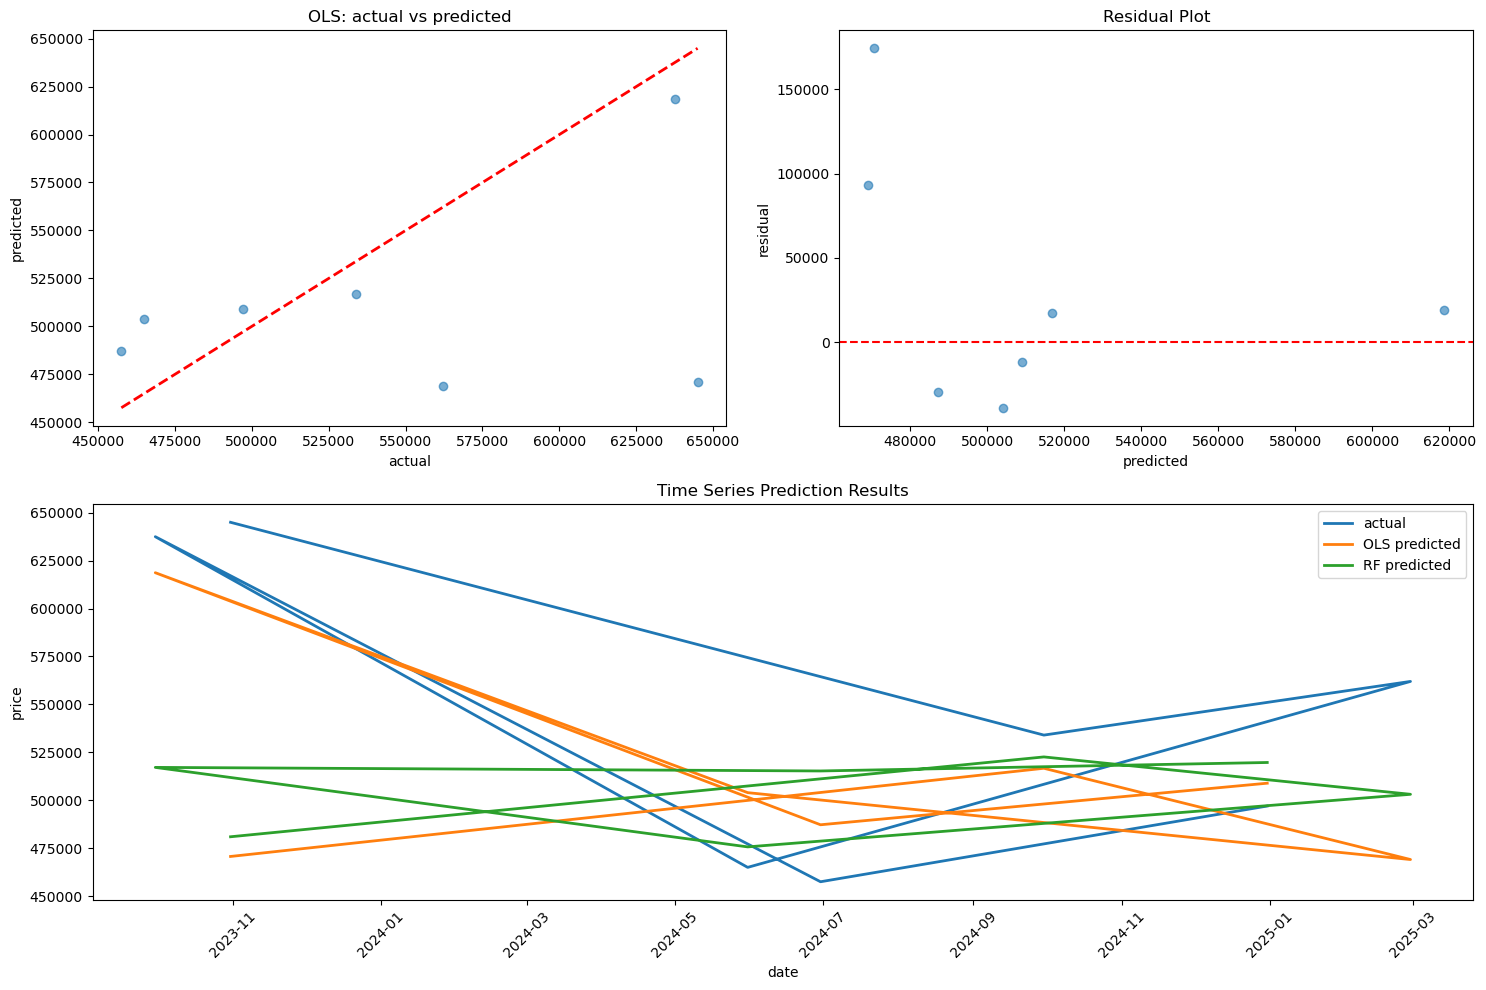

In [75]:
# 예측 결과 시각화
plt.figure(figsize=(15, 10))

# 실제값 vs 예측값
plt.subplot(2, 2, 1)
plt.scatter(y_test, predictions['OLS'], alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('OLS: actual vs predicted')

# 잔차 플롯
plt.subplot(2, 2, 2)
residuals_test = y_test - predictions['OLS']
plt.scatter(predictions['OLS'], residuals_test, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('predicted')
plt.ylabel('residual')
plt.title('Residual Plot')

# 시계열 예측 결과
plt.subplot(2, 1, 2)
test_dates = y_test.index
plt.plot(test_dates, y_test.values, label='actual', linewidth=2)
plt.plot(test_dates, predictions['OLS'], label='OLS predicted', linewidth=2)
plt.plot(test_dates, predictions['Random Forest'], label='RF predicted', linewidth=2)
plt.xlabel('date')
plt.ylabel('price')
plt.title('Time Series Prediction Results')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

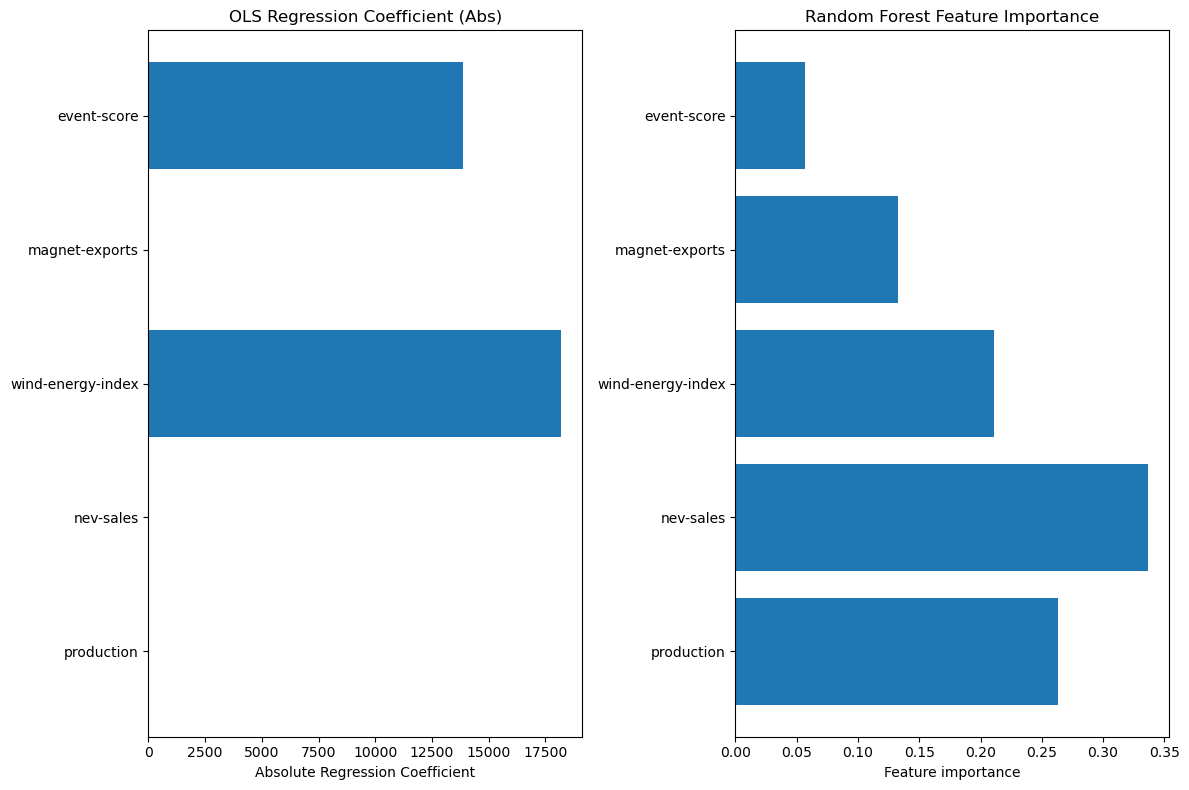

In [76]:
# 특성 중요도 시각화
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.barh(X_vars, np.abs(ols_coef))
plt.xlabel('Absolute Regression Coefficient')
plt.title('OLS Regression Coefficient (Abs)')

plt.subplot(1, 2, 2)
plt.barh(X_vars, rf_importance)
plt.xlabel('Feature importance')
plt.title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()

In [77]:
# 통계적 유의성 요약
print("\n=== 통계적 유의성 요약 ===")
significant_vars = []
for var, pval in zip(X_vars, ols_pvalues):
    if pval < 0.05:
        significant_vars.append(var)
        
print(f"유의수준 5%에서 통계적으로 유의한 변수: {significant_vars}")

if significant_vars:
    print(f"\n가장 영향력 있는 변수들:")
    for var in significant_vars:
        idx = X_vars.index(var)
        coef = ols_coef[idx]
        pval = ols_pvalues[idx]
        print(f"  {var}: 계수={coef:,.2f}, p-value={pval:.4f}")

# 경제적 해석
print("\n=== 경제적 해석 ===")
print("회귀계수의 경제적 의미:")
for var, coef in zip(X_vars, ols_coef):
    if coef > 0:
        print(f"• {var}: 1단위 증가 시 가격이 {coef:,.2f} 증가")
    else:
        print(f"• {var}: 1단위 증가 시 가격이 {abs(coef):,.2f} 감소")

# 모델 성능 요약표
performance_df = pd.DataFrame(results).T
print("\n=== 모델 성능 요약 ===")
print(performance_df.round(2))


=== 통계적 유의성 요약 ===
유의수준 5%에서 통계적으로 유의한 변수: ['production']

가장 영향력 있는 변수들:
  production: 계수=2.01, p-value=0.0038

=== 경제적 해석 ===
회귀계수의 경제적 의미:
• production: 1단위 증가 시 가격이 2.01 증가
• nev-sales: 1단위 증가 시 가격이 0.06 증가
• wind-energy-index: 1단위 증가 시 가격이 18,207.74 증가
• magnet-exports: 1단위 증가 시 가격이 0.00 감소
• event-score: 1단위 증가 시 가격이 13,873.06 감소

=== 모델 성능 요약 ===
                        MSE      RMSE       MAE    R²
OLS            6.030545e+09  77656.59  54846.88 -0.20
Ridge          5.768071e+09  75947.82  55823.87 -0.14
Lasso          6.030356e+09  77655.37  54847.57 -0.20
Random Forest  6.993866e+09  83629.33  63690.71 -0.39


C:\Users\User\AppData\Local\Temp\ipykernel_11984\2302469439.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_coef[idx]
C:\Users\User\AppData\Local\Temp\ipykernel_11984\2302469439.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_pvalues[idx]
